1.1 - Bibliotecas

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

1.2 - Carregar arquivos Parquet

In [20]:
DADOS_DIR = Path("../dados/consolidados")

#print(DADOS_DIR.resolve())
#print(list(DADOS_DIR.iterdir()))

mshl = pd.read_parquet(DADOS_DIR / "MSHL_consolidado.parquet")
cnes_lt = pd.read_parquet(DADOS_DIR / "LT_consolidado.parquet")
sih_rd = pd.read_parquet(DADOS_DIR / "RD_consolidado.parquet")

#Verificar se carregou corretamente
print("MSHL:", mshl.shape)
print("CNES-LT:", cnes_lt.shape)
print("SIH-RD:", sih_rd.shape)

MSHL: (2673, 9)
CNES-LT: (13079, 8)
SIH-RD: (696841, 20)


1.3 - Visão geral

In [21]:
dfs = {
    "MSHL": mshl,
    "CNES-LT": cnes_lt,
    "SIH-RD": sih_rd
}

resumo = []

for nome, df in dfs.items():
    resumo.append({
        "tabela": nome,
        "linhas": len(df),
        "colunas": len(df.columns),
        "memoria_mb": df.memory_usage(deep=True).sum() / 1024**2
    })

pd.DataFrame(resumo)

,tabela,linhas,colunas,memoria_mb
0,MSHL,2673,9,0.40
1,CNES-LT,13079,8,1.26
2,SIH-RD,696841,20,162.45


1.4 - Período dos dados

In [24]:
print("MSHL")
print(mshl["COMPETEN"].min(), mshl["COMPETEN"].max())

print("\nCNES-LT")
print(cnes_lt["COMPETEN"].min(), cnes_lt["COMPETEN"].max())

print("\nSIH-RD")
print(sih_rd["COMPETEN"].min(), sih_rd["COMPETEN"].max())

print("\nData mínima de internação:", sih_rd["DT_INTER"].min())
print("Data máxima de internação:", sih_rd["DT_INTER"].max())

print("Data mínima de saída:", sih_rd["DT_SAIDA"].min())
print("Data máxima de saída:", sih_rd["DT_SAIDA"].max())



MSHL
202401 202608

CNES-LT
202401 202607

SIH-RD
202401 202606

Data mínima de internação: 2022-03-05 00:00:00
Data máxima de internação: 2026-06-30 00:00:00
Data mínima de saída: 2023-08-01 00:00:00
Data máxima de saída: 2026-06-30 00:00:00


2. Qualidade — valores nulos

In [26]:
def resumo_nulos(df, nome_tabela):
    resultado = pd.DataFrame({
        "nulos": df.isna().sum(),
        "percentual_nulos": df.isna().mean() * 100,
        "tipo": df.dtypes.astype(str),
        "total": len(df)
    })
    
    resultado["tabela"] = nome_tabela
    
    return resultado.sort_values("percentual_nulos", ascending=False)

for nome, df in dfs.items():
    print(f"\n===== {nome} =====")
    display(resumo_nulos(df, nome))


===== MSHL =====


,nulos,percentual_nulos,tipo,total,tabela
CO_IBGE,983,36.78,string,2673,MSHL
COMPETEN,0,0.00,string,2673,MSHL
MUNICIPIO,0,0.00,string,2673,MSHL
CNES,0,0.00,string,2673,MSHL
NOME_ESTABELECIMENTO,0,0.00,string,2673,MSHL
RAZAO_SOCIAL,0,0.00,string,2673,MSHL
LEITOS_EXISTENTES,0,0.00,Int64,2673,MSHL
LEITOS_SUS,0,0.00,Int64,2673,MSHL
TP_GESTAO,0,0.00,string,2673,MSHL



===== CNES-LT =====


,nulos,percentual_nulos,tipo,total,tabela
CPF_CNPJ,1086,8.30,string,13079,CNES-LT
COMPETEN,0,0.00,string,13079,CNES-LT
CNES,0,0.00,string,13079,CNES-LT
CODUFMUN,0,0.00,string,13079,CNES-LT
TP_LEITO,0,0.00,string,13079,CNES-LT
CODLEITO,0,0.00,string,13079,CNES-LT
QT_EXIST,0,0.00,Int64,13079,CNES-LT
QT_SUS,0,0.00,Int64,13079,CNES-LT



===== SIH-RD =====


,nulos,percentual_nulos,tipo,total,tabela
CGC_HOSP,109943,15.78,string,696841,SIH-RD
UF_ZI,0,0.00,string,696841,SIH-RD
MES_CMPT,0,0.00,string,696841,SIH-RD
ANO_CMPT,0,0.00,string,696841,SIH-RD
ESPEC,0,0.00,string,696841,SIH-RD
MUNIC_MOV,0,0.00,string,696841,SIH-RD
QT_DIARIAS,0,0.00,Int64,696841,SIH-RD
DT_INTER,0,0.00,datetime64[ns],696841,SIH-RD
DT_SAIDA,0,0.00,datetime64[ns],696841,SIH-RD
DIAS_PERM,0,0.00,Int64,696841,SIH-RD


3. Duplicidades

In [27]:
for nome, df in dfs.items():
    print(f"{nome}:")
    print("Linhas:", len(df))
    print("Duplicadas completas:", df.duplicated().sum())
    print()

    sih_rd["N_AIH"].nunique()

    sih_rd["N_AIH"].value_counts().head(20)

    sih_rd.groupby("N_AIH").size().value_counts().sort_index()

MSHL:
Linhas: 2673
Duplicadas completas: 0

CNES-LT:
Linhas: 13079
Duplicadas completas: 0

SIH-RD:
Linhas: 696841
Duplicadas completas: 0



4. Validação do tempo de permanência

In [28]:
sih_rd["PERM_CALCULADA"] = (
    sih_rd["DT_SAIDA"] - sih_rd["DT_INTER"]
).dt.days

sih_rd[["DIAS_PERM", "PERM_CALCULADA"]].describe()

(
    sih_rd["DIAS_PERM"] != sih_rd["PERM_CALCULADA"]
).value_counts()

sih_rd["DIF_PERM"] = (
    sih_rd["DIAS_PERM"] - sih_rd["PERM_CALCULADA"]
)

sih_rd["DIF_PERM"].value_counts().sort_index()

DIF_PERM
-787         1
-757         1
-726         1
-697         1
-666         1
         ...  
-4         120
-3         122
-2         144
-1         145
0       694364
Name: count, Length: 192, dtype: Int64

5. Datas inconsistentes

In [29]:
sih_rd[sih_rd["DT_SAIDA"] < sih_rd["DT_INTER"]].shape

sih_rd[sih_rd["DIAS_PERM"] < 0].shape

(0, 22)

6. Valores extremos de permanência

In [33]:
sih_rd["DIAS_PERM"].describe(percentiles=[
    .01, .05, .25, .50, .75, .90, .95, .99
])

sih_rd.nlargest(20, "DIAS_PERM")[
    ["CNES", "N_AIH", "DT_INTER", "DT_SAIDA", "DIAS_PERM", "IDADE", "SEXO"]
]

,CNES,N_AIH,DT_INTER,DT_SAIDA,DIAS_PERM,IDADE,SEXO
301161,0000426,2625101745024,2024-01-08,2024-12-31,358,47,1
78070,0000671,2623108689256,2023-01-30,2023-12-14,318,0,3
274330,0000426,2624101795942,2024-01-29,2024-12-02,308,75,1
44303,0000426,2624101563138,2023-02-19,2023-12-20,304,14,3
380157,3983730,2625101602706,2024-08-02,2025-04-01,242,64,1
103338,3983730,2624101402879,2023-08-06,2024-03-28,235,56,1
223239,0000671,2624108711631,2024-01-25,2024-07-27,184,26,3
176096,3983730,2624101408270,2024-01-04,2024-07-03,181,55,1
208028,3983730,2624101427300,2024-02-21,2024-08-01,162,61,1
114850,3983730,2624101404353,2023-11-09,2024-04-18,161,48,1


7 - Visualização gráfica - Boxplot

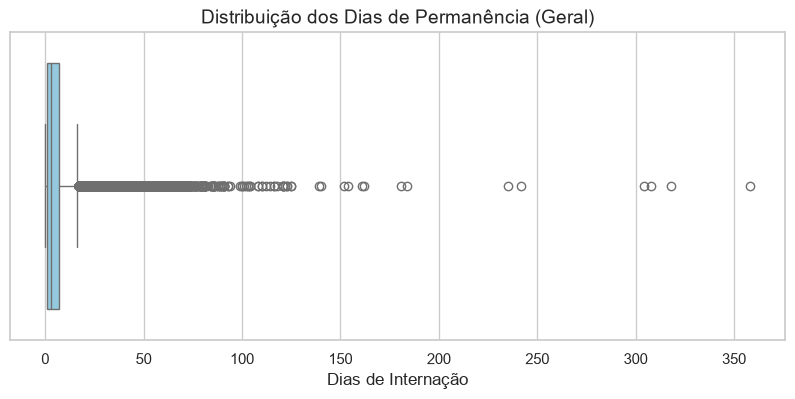

In [34]:
# Configura o estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 4))

# Opção 1: Boxplot da base completa
sns.boxplot(x=sih_rd["DIAS_PERM"], color="skyblue")

plt.title("Distribuição dos Dias de Permanência (Geral)", fontsize=14)
plt.xlabel("Dias de Internação", fontsize=12)
plt.show()

8 - Visualização gráfica - Boxplot (Sem os Outliers Extremos, percentil 99%)

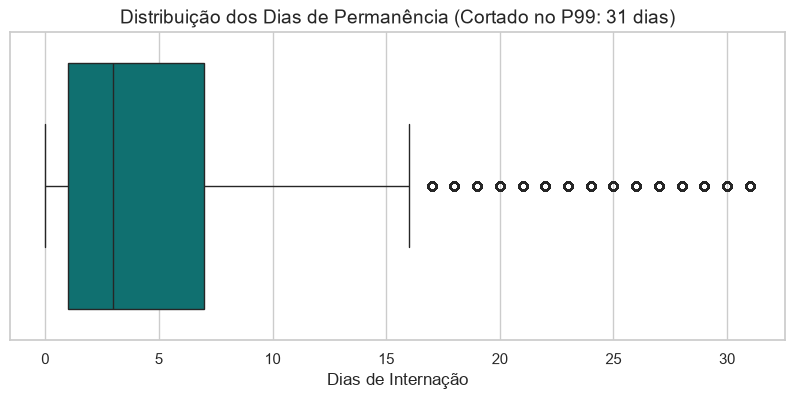

In [35]:
# Descobre o valor do percentil 99% para usar como limite visual
limite_p99 = sih_rd["DIAS_PERM"].quantile(0.99)

plt.figure(figsize=(10, 4))

# Plota o boxplot apenas para os dados dentro do limite de 99%
sns.boxplot(
    x=sih_rd[sih_rd["DIAS_PERM"] <= limite_p99]["DIAS_PERM"], color="teal"
)

plt.title(
    f"Distribuição dos Dias de Permanência (Cortado no P99: {limite_p99:.0f} dias)",
    fontsize=14,
)
plt.xlabel("Dias de Internação", fontsize=12)
plt.show()

In [37]:
# 1. Cálculos base
media = sih_rd["DIAS_PERM"].mean()
mediana = sih_rd["DIAS_PERM"].median()
moda = sih_rd["DIAS_PERM"].mode()[0]  # [0] garante o valor se houver mais de uma moda

# 2. Métricas de dispersão
desvio_padrao = sih_rd["DIAS_PERM"].std()
coef_variacao = (desvio_padrao / media) * 100

# Exibindo os resultados formatados
print("--- Tendência Central ---")
print(f"Média:                  {media:.2f} dias")
print(f"Mediana:                {mediana:.1f} dias")
print(f"Moda:                   {moda:.0f} dias")
print("\n--- Dispersão ---")
print(f"Desvio Padrão:          {desvio_padrao:.2f} dias")
print(f"Coeficiente de Variação: {coef_variacao:.1f}%")

--- Tendência Central ---
Média:                  5.47 dias
Mediana:                3.0 dias
Moda:                   0 dias

--- Dispersão ---
Desvio Padrão:          7.04 dias
Coeficiente de Variação: 128.6%
